# Interbank Network Data Exploration

**Author:** Ruben Marques  
**Purpose:** Comprehensive analysis of the interbank network dataset (2016-2023)

This notebook explores:
1. Dataset overview and structure
2. Network topology and connectivity
3. Bank features and distributions
4. Credit rating analysis
5. Temporal evolution
6. SRISK analysis

In [ ]:
# Parameters
YEAR = 2020
QUARTER = 1
TOP_N = 100


In [3]:
# Import libraries
import sys
import os

# Add src to path
sys.path.append(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(os.getcwd(), '..', 'src', 'data'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from src.data.data_loader import load_data

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [4]:
import os
print(os.getcwd())


/Users/rubenmarques/Documents/Repositórios/Thesis/notebooks


---
## 1. Dataset Overview

Load and examine the basic structure of the dataset.

In [8]:
# Testing data loading
year, quarter = YEAR, QUARTER

test_edges, test_nodes = load_data(year, quarter)

Loaded 2020 Q1: 4548 banks, 12424 edges


In [9]:
print(test_nodes.columns)

Index(['index', 'Total_assets', 'Total_liabilities', 'Equity', 'Liquid_assets',
       'Deposits_and_short-term_funding', 'Long-term_funding', 'Net_income',
       'Interbank_assets', 'Interbank_liabilities',
       'Return_on_average_equity_(ROAE)', 'Wholesale_funding',
       'Growth_in_total_assets',
       'Impaired_loans_/_Gross_customer_loans_&_advances',
       'Loan_loss_reserves_/_Impaired_loans',
       'Customer_loans_&_advances_/_Total_assets',
       'Net_charge_offs_(NCOs)_/_Average_gross_customer_loans_&_advances',
       'Unreserved_impaired_loans_/_Total_equity',
       'Total_Common_Equity_/_Core_Tier_1', 'Total_Capital',
       'Exchange_rate_from_original_currency',
       'Gross_loans_&_advances_to_customers',
       'Wholesale_funding_/_Total_funding_excluding_derivatives',
       'Loans_&_advances_to_customers_/_Total_deposits_&_other_interest-bearing_liabilities',
       'Financial_assets:_Available_for_sale_(AFS)', 'Total_Earning_Assets',
       'Unadjusted_lev

| Column Actual Name | Ratio Name / Meaning |
| :--- | :--- |
| `index` | N/A (Index/ID) |
| `Total_assets` | N/A (Raw Data) |
| `Total_liabilities` | N/A (Raw Data) |
| `Equity` | N/A (Raw Data) |
| `Liquid_assets` | N/A (Raw Data) |
| `Deposits_and_short-term_funding` | N/A (Raw Data) |
| `Long-term_funding` | N/A (Raw Data) |
| `Net_income` | N/A (Raw Data) |
| `Interbank_assets` | N/A (Raw Data) |
| `Interbank_liabilities` | N/A (Raw Data) |
| `Return_on_average_equity_(ROAE)` | **Return on Average Equity (ROAE)** |
| `Wholesale_funding` | N/A (Raw Data) |
| `Growth_in_total_assets` | **Asset Growth Rate** |
| `Impaired_loans_/_Gross_customer_loans_&_advances` | **Non-Performing Loan (NPL) Ratio** |
| `Loan_loss_reserves_/_Impaired_loans` | **NPL Coverage Ratio** |
| `Customer_loans_&_advances_/_Total_assets` | **Loan-to-Asset Ratio** |
| `Net_charge_offs_(NCOs)_/_Average_gross_customer_loans_&_advances` | **Net Charge-off Ratio** |
| `Unreserved_impaired_loans_/_Total_equity` | **Texas Ratio (Variant) / Capital at Risk** |
| `Total_Common_Equity_/_Core_Tier_1` | **Capital Composition Ratio** |
| `Total_Capital` | N/A (Raw Data) |
| `Exchange_rate_from_original_currency` | N/A (FX Rate) |
| `Gross_loans_&_advances_to_customers` | N/A (Raw Data) |
| `Wholesale_funding_/_Total_funding_excluding_derivatives` | **Wholesale Funding Dependency Ratio** |
| `Loans_&_advances_to_customers_/_Total_deposits_&_other_interest-bearing_liabilities` | **Loan-to-Deposit Ratio (Broad)** |
| `Financial_assets:_Available_for_sale_(AFS)` | N/A (Raw Data) |
| `Total_Earning_Assets` | N/A (Raw Data) |
| `Unadjusted_leverage_ratio_(computed)` | **Leverage Ratio (Basel III)** |
| `Tier_1_Ratio` | **Tier 1 Capital Ratio** |
| `Interest_Expense` | N/A (Raw Data) |
| `Tier_1_Capital` | N/A (Raw Data) |
| `Long-term_borrowings_and_debt_securities_at_historical_cost_>_1_year` | N/A (Raw Data) |
| `Impaired_/_Non-performing_loans_to_customers` | N/A (Likely Raw NPL Volume) |
| `Other_reserves` | N/A (Raw Data) |
| `Interest_expense_on_customer_deposits` | N/A (Raw Data) |
| `Interest_expense_/_average_interest_bearing_liabilities` | **Cost of Funds** |
| `Interest_expense_on_customer_deposits_/_Average_customer_deposits` | **Cost of Deposits** |
| `Total_capital_adequacy_ratio` | **Capital Adequacy Ratio (CAR)** |
| `Interest_income_/_average_interest_earning_assets` | **Asset Yield / Gross Yield** |
| `Interest_income_on_bank_loans_(including_central_banks)` | N/A (Raw Data) |
| `Other_administrative_expenses` | N/A (Raw Data) |
| `Interest_income_on_loans_/_Average_gross_customer_loans_&_advances` | **Loan Yield** |
| `Other_interest_income` | N/A (Raw Data) |
| `Effective_tax_rate` | **Effective Tax Rate** |
| `Total_net_trading_income_(losses)_and_fair_value_(FV)_gains_(losses)` | N/A (Raw Data) |
| `Savings_deposits` | N/A (Raw Data) |
| `Total_equity_/_Risk-weighted_assets_(RWAs)` | **Equity-to-RWA Ratio** |
| `Growth_in_net_customer_loans_&_advances` | **Net Loan Growth Rate** |
| `Net_loans_&_advances_to_customers` | N/A (Raw Data) |
| `Net_gains_(losses)_on_other_securities_(including_FV_through_OCI)` | N/A (Raw Data) |
| `Customer_deposits_/_Total_funding_excluding_derivatives` | **Deposit Funding Ratio** |
| `Operating_revenue_after_impairments` | N/A (Raw Data) |
| `Net_interest_income_(expenses)_/_Average_total_assets` | **Return on Assets (Net Interest Component)** |
| `Liquid_assets_(including_available_for_sale_&_held_to_maturity)_/_Total_assets` | **Liquid Asset Ratio** |
| `Impaired_loans_+_foreclosed_assets_/_gross_customer_loans_&_advances_+_foreclosed_assets` | **Non-Performing Asset (NPA) Ratio** |
| `Financial_assets:_Held_to_maturity_(HTM)` | N/A (Raw Data) |
| `Risk_weighted_asset_intensity_(RWA_/_Total_Assets)` | **RWA Density / RWA Intensity** |
| `Minimum_risk_assets` | N/A (Raw Data) |
| `Gross_loans_&_advances_to_customers_/_Customer_deposits` | **Loan-to-Deposit Ratio (LDR)** |
| `Number_of_employees` | N/A (Raw Data) |
| `Net_interest_margin_(average_interest_earning_assets)` | **Net Interest Margin (NIM)** |
| `Loans_&_advances_to_customers_/_Deposits_&_short-term_funding` | **Liquidity Ratio (Loans to Short-term Funding)** |
| `Profit_attributable_to_group_equity_holders` | N/A (Raw Data) |
| `Interest_income_on_customer_loans_&_advances` | N/A (Raw Data) |
| `Total_other_earning_assets` | N/A (Raw Data) |
| `Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities` | **Equity-to-Liability Ratio** |
| `Capital_funds_/_Total_assets` | **Equity Multiplier / Simple Leverage Ratio** |
| `Growth_in_gross_customer_loans_&advances` | **Gross Loan Growth Rate** |
| `Capital_funds_/_Net_loans_&_advances_to_customers` | **Capital-to-Loan Ratio** |
| `Time_deposits` | N/A (Raw Data) |
| `Non-interest_income_/_Operating_revenues` | **Non-Interest Income Ratio** |
| `Net_interest_margin_(interest_earning_assets)` | **Net Interest Margin (NIM)** |
| `rank_next_quarter` | N/A (Predictive Target) |
| `srisk_ratio` | **SRISK Ratio (Systemic Risk)** |
| `srisk_value` | N/A (Raw Data) |

In [15]:
stats = test_nodes.describe()
stats

,index,Total_assets,Total_liabilities,Equity,Liquid_assets,Deposits_and_short-term_funding,Long-term_funding,Net_income,Interbank_assets,Interbank_liabilities,Return_on_average_equity_(ROAE),Wholesale_funding,Growth_in_total_assets,Impaired_loans_/_Gross_customer_loans_&_advances,Loan_loss_reserves_/_Impaired_loans,Customer_loans_&_advances_/_Total_assets,Net_charge_offs_(NCOs)_/_Average_gross_customer_loans_&_advances,Unreserved_impaired_loans_/_Total_equity,Total_Common_Equity_/_Core_Tier_1,Total_Capital,Exchange_rate_from_original_currency,Gross_loans_&_advances_to_customers,Wholesale_funding_/_Total_funding_excluding_derivatives,Loans_&_advances_to_customers_/_Total_deposits_&_other_interest-bearing_liabilities,Financial_assets:_Available_for_sale_(AFS),Total_Earning_Assets,Unadjusted_leverage_ratio_(computed),Tier_1_Ratio,Interest_Expense,Tier_1_Capital,Long-term_borrowings_and_debt_securities_at_historical_cost_>_1_year,Impaired_/_Non-performing_loans_to_customers,Other_reserves,Interest_expense_on_customer_deposits,Interest_expense_/_average_interest_bearing_liabilities,Interest_expense_on_customer_deposits_/_Average_customer_deposits,Total_capital_adequacy_ratio,Interest_income_/_average_interest_earning_assets,Interest_income_on_bank_loans_(including_central_banks),Other_administrative_expenses,Interest_income_on_loans_/_Average_gross_customer_loans_&_advances,Other_interest_income,Effective_tax_rate,Total_net_trading_income_(losses)_and_fair_value_(FV)_gains_(losses),Savings_deposits,Total_equity_/_Risk-weighted_assets_(RWAs),Growth_in_net_customer_loans_&_advances,Net_loans_&_advances_to_customers,Net_gains_(losses)_on_other_securities_(including_FV_through_OCI),Customer_deposits_/_Total_funding_excluding_derivatives,Operating_revenue_after_impairments,Net_interest_income_(expenses)_/_Average_total_assets,Liquid_assets_(including_available_for_sale_&_held_to_maturity)_/_Total_assets,Impaired_loans_+_foreclosed_assets_/_gross_customer_loans_&_advances_+_foreclosed_assets,Financial_assets:_Held_to_maturity_(HTM),Risk_weighted_asset_intensity_(RWA_/_Total_Assets),Minimum_risk_assets,Gross_loans_&_advances_to_customers_/_Customer_deposits,Number_of_employees,Net_interest_margin_(average_interest_earning_assets),Loans_&_advances_to_customers_/_Deposits_&_short-term_funding,Profit_attributable_to_group_equity_holders,Interest_income_on_customer_loans_&_advances,Total_other_earning_assets,Total_equity_/_Total_liabilities_excluding_hybrid_capital_and_subordinated_liabilities,Capital_funds_/_Total_assets,Growth_in_gross_customer_loans_&advances,Capital_funds_/_Net_loans_&_advances_to_customers,Time_deposits,Non-interest_income_/_Operating_revenues,Net_interest_margin_(interest_earning_assets),rank_next_quarter,srisk_ratio,srisk_value
count,4548.000000,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4548.000000,4.548000e+03,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4.548000e+03,4.548000e+03,4548.000000,4.548000e+03,4548.000000,4548.000000,4.548000e+03,4.548000e+03,4548.000000,4548.000000,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4.548000e+03,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4.548000e+03,4548.000000,4.548000e+03,4548.000000,4.548000e+03,4.548000e+03,4548.000000,4548.000000,4.548000e+03,4548.000000,4548.000000,4.548000e+03,4548.000000,4548.000000,4548.000000,4.548000e+03,4548.000000,4.548000e+03,4548.000000,4548.000000,4548.000000,4548.000000,4.548000e+03,4.548000e+03,4.548000e+03,4548.000000,4548.000000,4548.000000,4548.000000,4.548000e+03,4548.000000,4548.000000,4548.000000,284.000000,284.000000
mean,2273.500000,7.948228e+06,7.235600e+06,7.021592e+05,2.621039e+06,5.959496e+06,6.048722e+05,1.139715e+04,6.710099e+05,4.985251e+05,8.215990,1.363927e+06,2.527995,1.107679,1045.428143,63.244760,0.032973,-1.581102,5.139098e+05,6.476234e+05,0.977705,4.343878e+06,5.182388,72.941093,9.17433

---
## 2. Network Topology Analysis

Analyze the structure and connectivity of the interbank network.

In [16]:
# Create NetworkX graph
G = nx.DiGraph()

# Add edges with weights
for _, row in test_edges.iterrows():
    G.add_edge(row['Sourceid'], row['Targetid'], weight=row['Weights'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Is directed: {G.is_directed()}")
print(f"Is connected: {nx.is_weakly_connected(G)}")

Graph created with 4349 nodes and 12424 edges
Is directed: True
Is connected: True


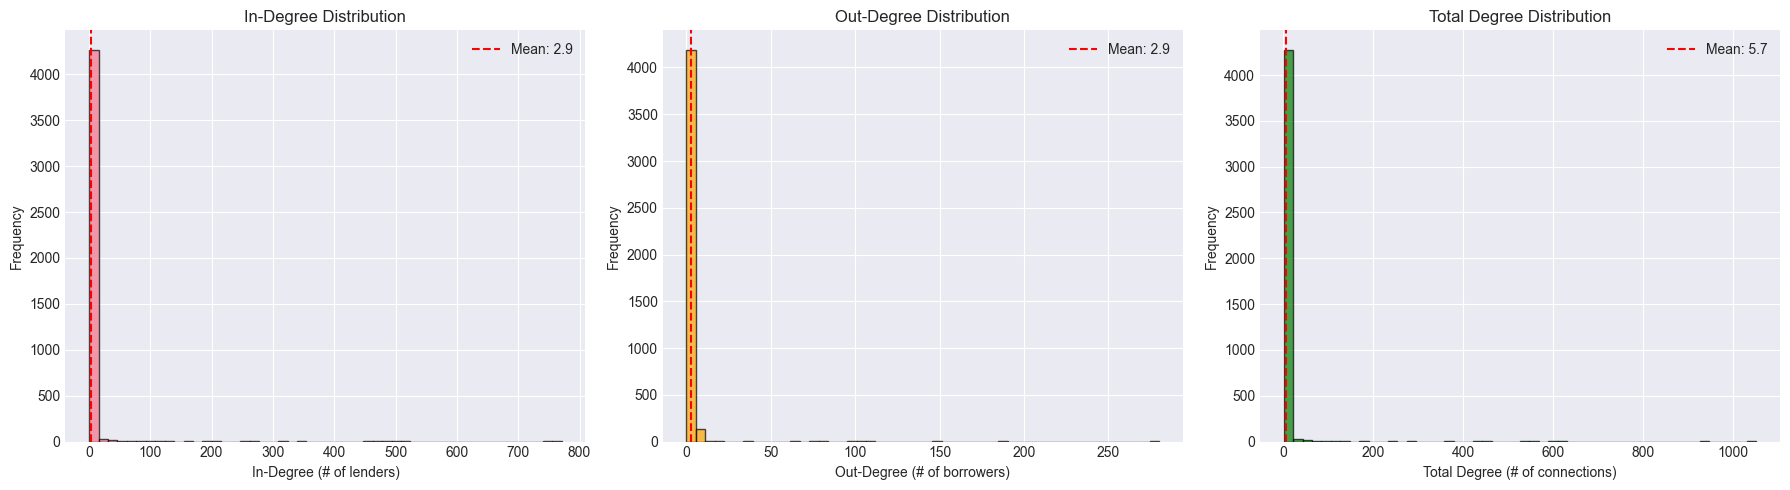

Average in-degree: 2.86
Average out-degree: 2.86
Average total degree: 5.71


In [17]:
# Degree distribution
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = dict(G.degree())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# In-degree
axes[0].hist(list(in_degrees.values()), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('In-Degree (# of lenders)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('In-Degree Distribution')
axes[0].axvline(np.mean(list(in_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(in_degrees.values())):.1f}')
axes[0].legend()

# Out-degree
axes[1].hist(list(out_degrees.values()), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Out-Degree (# of borrowers)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Out-Degree Distribution')
axes[1].axvline(np.mean(list(out_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(out_degrees.values())):.1f}')
axes[1].legend()

# Total degree
axes[2].hist(list(total_degrees.values()), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Total Degree (# of connections)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Total Degree Distribution')
axes[2].axvline(np.mean(list(total_degrees.values())), color='r', linestyle='--', label=f'Mean: {np.mean(list(total_degrees.values())):.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Average in-degree: {np.mean(list(in_degrees.values())):.2f}")
print(f"Average out-degree: {np.mean(list(out_degrees.values())):.2f}")
print(f"Average total degree: {np.mean(list(total_degrees.values())):.2f}")

- Average in-degree: 2.86 On average, an entity receives funds from 2.86 distinct counterparties.

- Average out-degree: 2.86 On average, an entity sends funds to 2.86 distinct counterparties.

- Average total degree: 5.71 On average, an entity maintains financial relationships with 5.71 unique partners total.

/Users/rubenmarques/Documents/Repositórios/Thesis/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


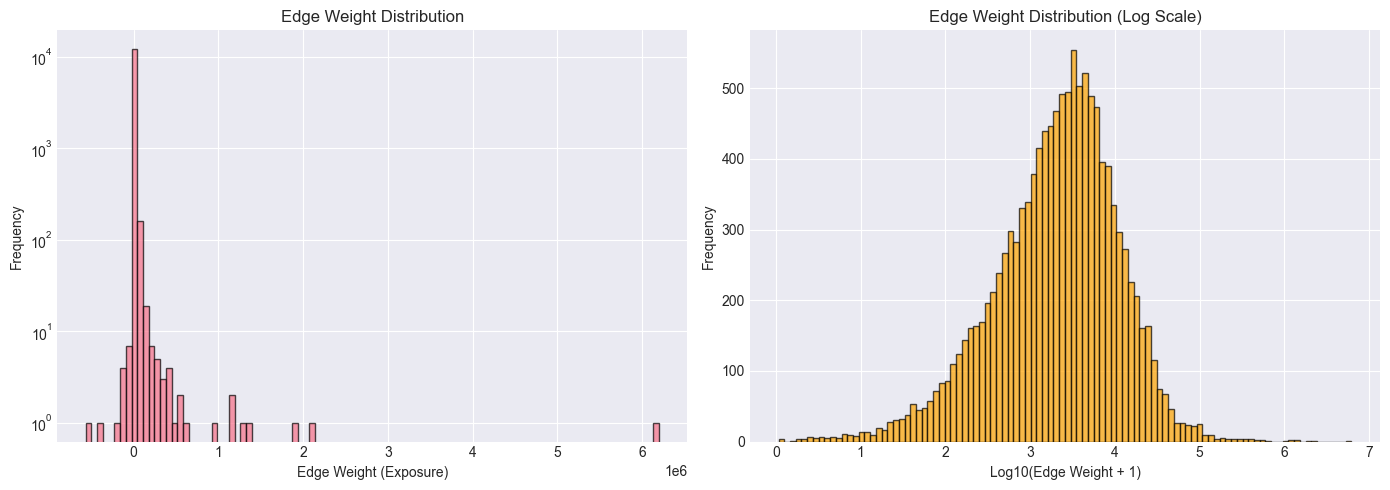

Total exposure: $94,168,372
Mean exposure: $7,580
Median exposure: $2,381
Max exposure: $6,192,340
Min exposure: $-563,443


In [20]:
# Edge weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw weights
axes[0].hist(test_edges['Weights'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Edge Weight (Exposure)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Edge Weight Distribution')
axes[0].set_yscale('log')

# Log weights
axes[1].hist(np.log10(test_edges['Weights'] + 1), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log10(Edge Weight + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Edge Weight Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f"Total exposure: ${test_edges['Weights'].sum():,.0f}")
print(f"Mean exposure: ${test_edges['Weights'].mean():,.0f}")
print(f"Median exposure: ${test_edges['Weights'].median():,.0f}")
print(f"Max exposure: ${test_edges['Weights'].max():,.0f}")
print(f"Min exposure: ${test_edges['Weights'].min():,.0f}")

---
## 3. Bank Features Analysis

Examine the distribution of bank financial features.

In [21]:
# Get feature columns (exclude index and last 3 columns)
feature_cols = test_nodes.columns[1:-3].tolist()

print(f"Total features: {len(feature_cols)}")
print(f"\nFirst 10 features:")
for i, col in enumerate(feature_cols[:10], 1):
    print(f"{i:2d}. {col}")

Total features: 70

First 10 features:
 1. Total_assets
 2. Total_liabilities
 3. Equity
 4. Liquid_assets
 5. Deposits_and_short-term_funding
 6. Long-term_funding
 7. Net_income
 8. Interbank_assets
 9. Interbank_liabilities
10. Return_on_average_equity_(ROAE)


In [22]:
# Check for missing values
missing = test_nodes[feature_cols].isnull().sum()
missing_pct = (missing / len(test_nodes)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("FEATURES WITH MISSING VALUES")
print("=" * 60)
display(missing_df[missing_df['Missing Count'] > 0].head(20))

print(f"\nFeatures with >50% missing: {(missing_pct > 50).sum()}")
print(f"Features with no missing values: {(missing == 0).sum()}")

FEATURES WITH MISSING VALUES


,Missing Count,Missing %



Features with >50% missing: 0
Features with no missing values: 70


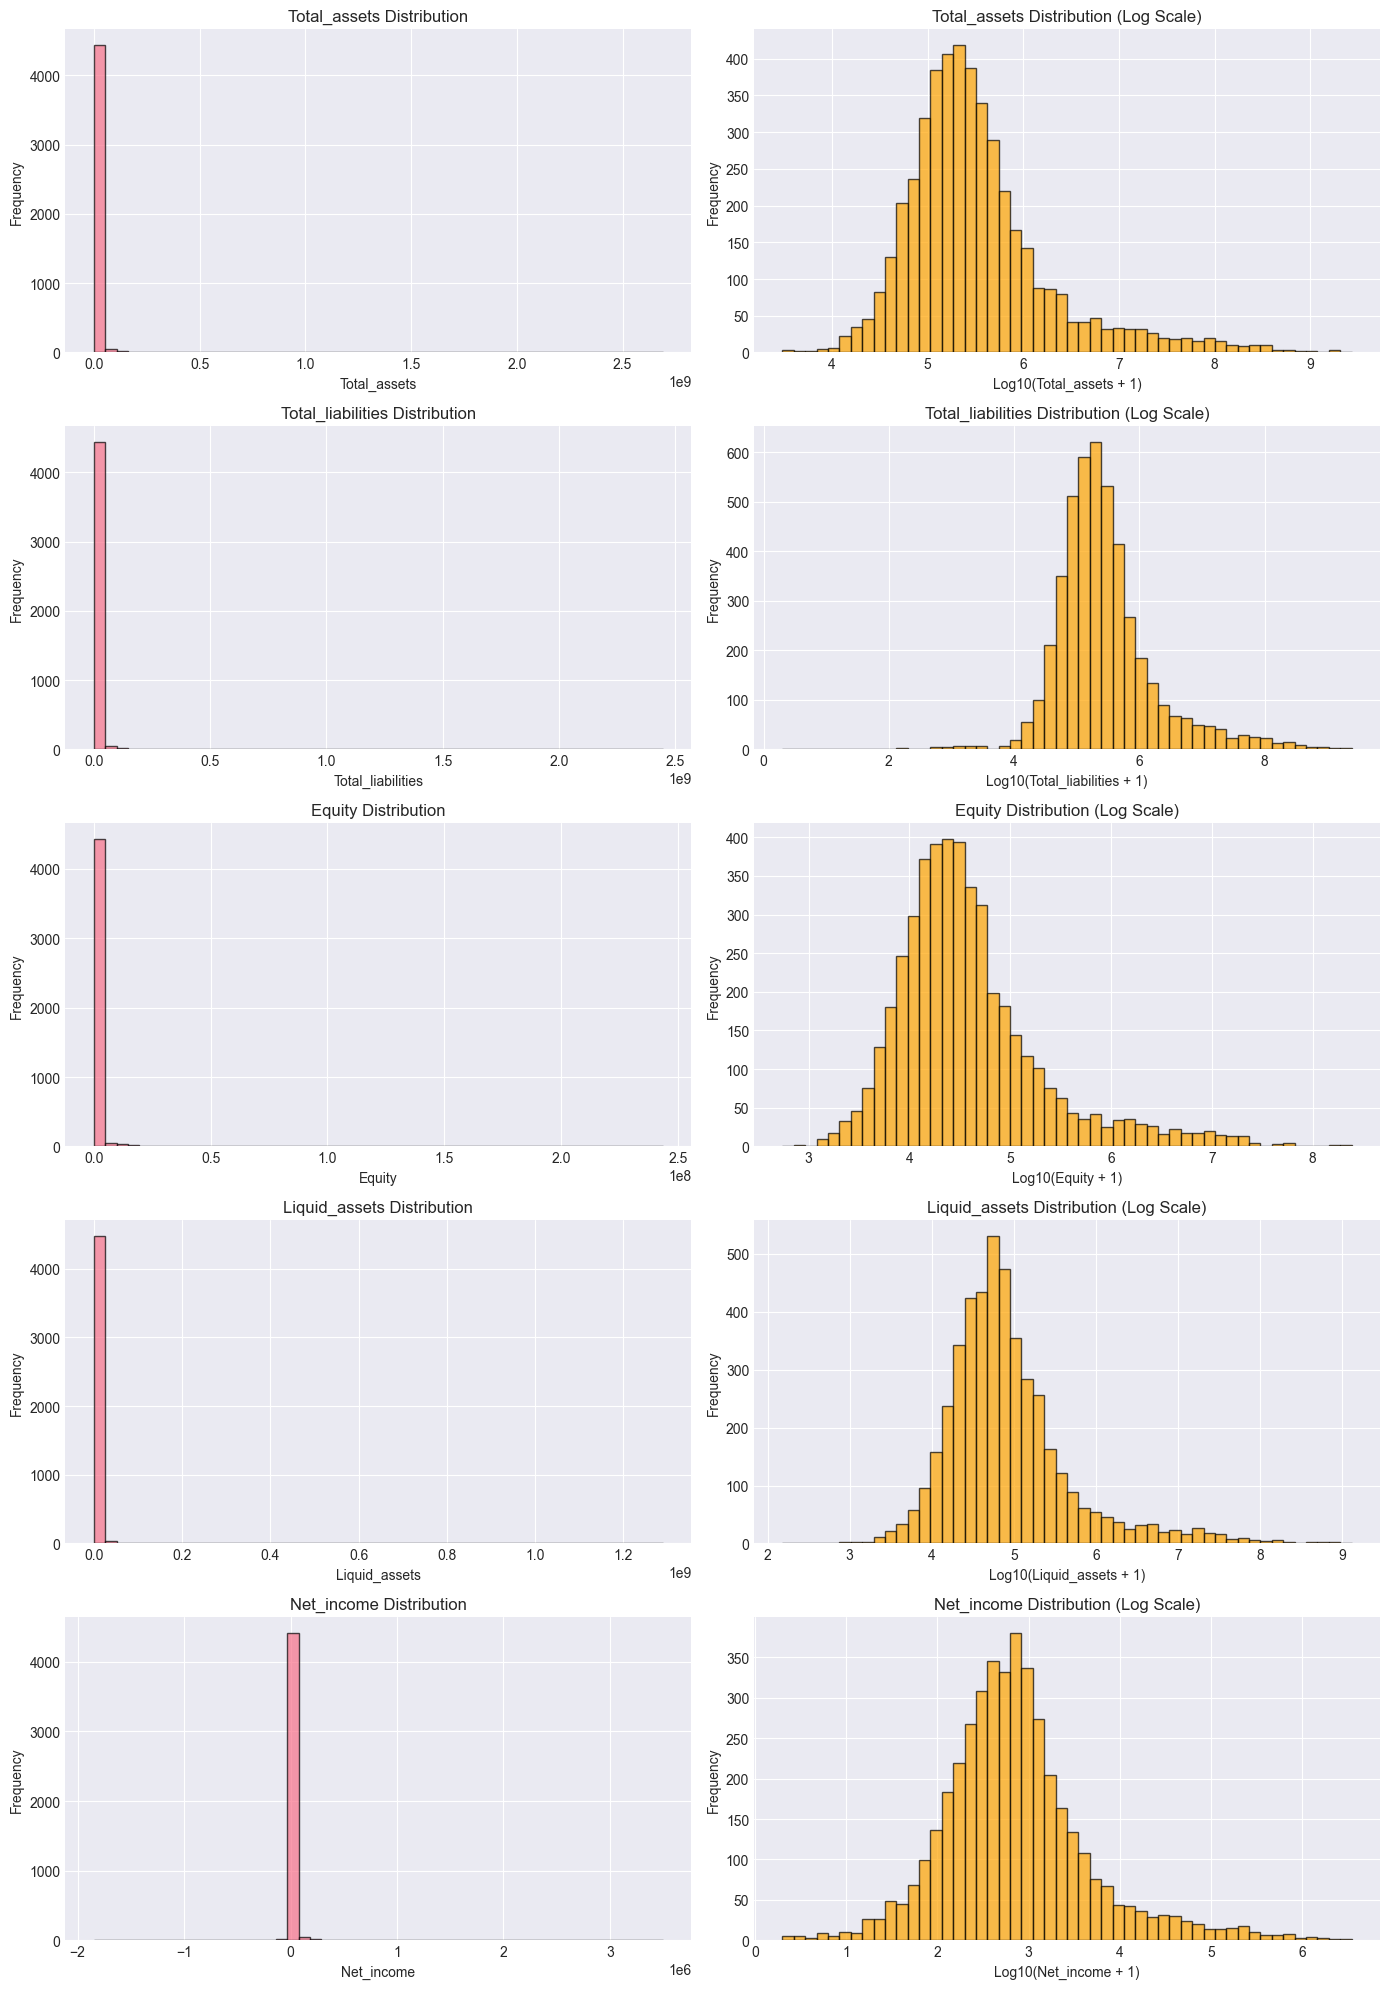

In [23]:
# Distribution of key financial features
key_features = ['Total_assets', 'Total_liabilities', 'Equity', 'Liquid_assets', 'Net_income']

# Check which features exist
available_features = [f for f in key_features if f in test_nodes.columns]

if available_features:
    fig, axes = plt.subplots(len(available_features), 2, figsize=(14, 4*len(available_features)))
    
    for i, feature in enumerate(available_features):
        data = test_nodes[feature].dropna()
        
        # Original scale
        axes[i, 0].hist(data, bins=50, edgecolor='black', alpha=0.7)
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel('Frequency')
        axes[i, 0].set_title(f'{feature} Distribution')
        
        # Log scale
        log_data = np.log10(data[data > 0] + 1)
        axes[i, 1].hist(log_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[i, 1].set_xlabel(f'Log10({feature} + 1)')
        axes[i, 1].set_ylabel('Frequency')
        axes[i, 1].set_title(f'{feature} Distribution (Log Scale)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Key features not found in dataset")

---
## 6. Temporal Evolution (2016-2023)

Analyze how the network evolves over time.

In [28]:
# Load all quarters and track evolution
years = range(2016, 2023)
quarters = range(1, 5)

timeline_data = []

for year in years:
    for quarter in quarters:
        try:
            edges_t, nodes_t = load_data(year, quarter)
            stats_t = nodes_t.describe()
            stats_t['num_connections'] = edges_t.shape[0]
            stats_t['total_exposure'] = edges_t['Weights'].sum()
            labels_t = nodes_t
            timeline_data.append({
                'year': year,
                'quarter': quarter,
                'period': f"{year}Q{quarter}",
                'rating_A': (labels_t['srisk_value'] == 1).sum(),
                'rating_B': (labels_t['srisk_value'] == 2).sum(),
                'rating_C': (labels_t['srisk_value'] == 3).sum(),
                'rating_D': (labels_t['srisk_value'] == 4).sum(),
                'rating_E': (labels_t['srisk_value'] == 5).sum(),
                'rating_F': (labels_t['srisk_value'] == 6).sum(),
            })
        except FileNotFoundError:
            print(f"Data not found for {year} Q{quarter}")
            continue

timeline_df = pd.DataFrame(timeline_data)
print(f"Loaded {len(timeline_df)} quarters of data")
display(timeline_df.head(10))

Loaded 2016 Q1: 4548 banks, 11631 edges
Loaded 2016 Q2: 4548 banks, 11632 edges
Loaded 2016 Q3: 4548 banks, 11937 edges
Loaded 2016 Q4: 4548 banks, 11938 edges
Loaded 2017 Q1: 4548 banks, 11939 edges
Loaded 2017 Q2: 4548 banks, 11940 edges
Loaded 2017 Q3: 4548 banks, 11941 edges
Loaded 2017 Q4: 4548 banks, 11981 edges
Loaded 2018 Q1: 4548 banks, 12416 edges
Loaded 2018 Q2: 4548 banks, 12417 edges
Loaded 2018 Q3: 4548 banks, 12418 edges
Loaded 2018 Q4: 4548 banks, 12419 edges
Loaded 2019 Q1: 4548 banks, 12420 edges
Loaded 2019 Q2: 4548 banks, 12421 edges
Loaded 2019 Q3: 4548 banks, 12422 edges
Loaded 2019 Q4: 4548 banks, 12423 edges
Loaded 2020 Q1: 4548 banks, 12424 edges
Loaded 2020 Q2: 4548 banks, 12451 edges
Loaded 2020 Q3: 4548 banks, 12452 edges
Loaded 2020 Q4: 4548 banks, 12453 edges
Loaded 2021 Q1: 4548 banks, 12454 edges
Loaded 2021 Q2: 4548 banks, 12455 edges
Loaded 2021 Q3: 4548 banks, 12456 edges
Loaded 2021 Q4: 4548 banks, 12457 edges
Loaded 2022 Q1: 4548 banks, 12458 edges


,year,quarter,period,rating_A,rating_B,rating_C,rating_D,rating_E,rating_F
0,2016,1,2016Q1,0,0,0,0,0,0
1,2016,2,2016Q2,0,0,0,0,0,0
2,2016,3,2016Q3,0,0,0,0,0,0
3,2016,4,2016Q4,0,0,0,0,0,0
4,2017,1,2017Q1,0,0,0,0,0,0
5,2017,2,2017Q2,0,0,0,0,0,0
6,2017,3,2017Q3,0,0,0,0,0,0
7,2017,4,2017Q4,0,0,0,0,0,0
8,2018,1,2018Q1,0,0,0,0,0,0
9,2018,2,2018Q2,0,0,0,0,0,0


KeyError: 'total_exposure'

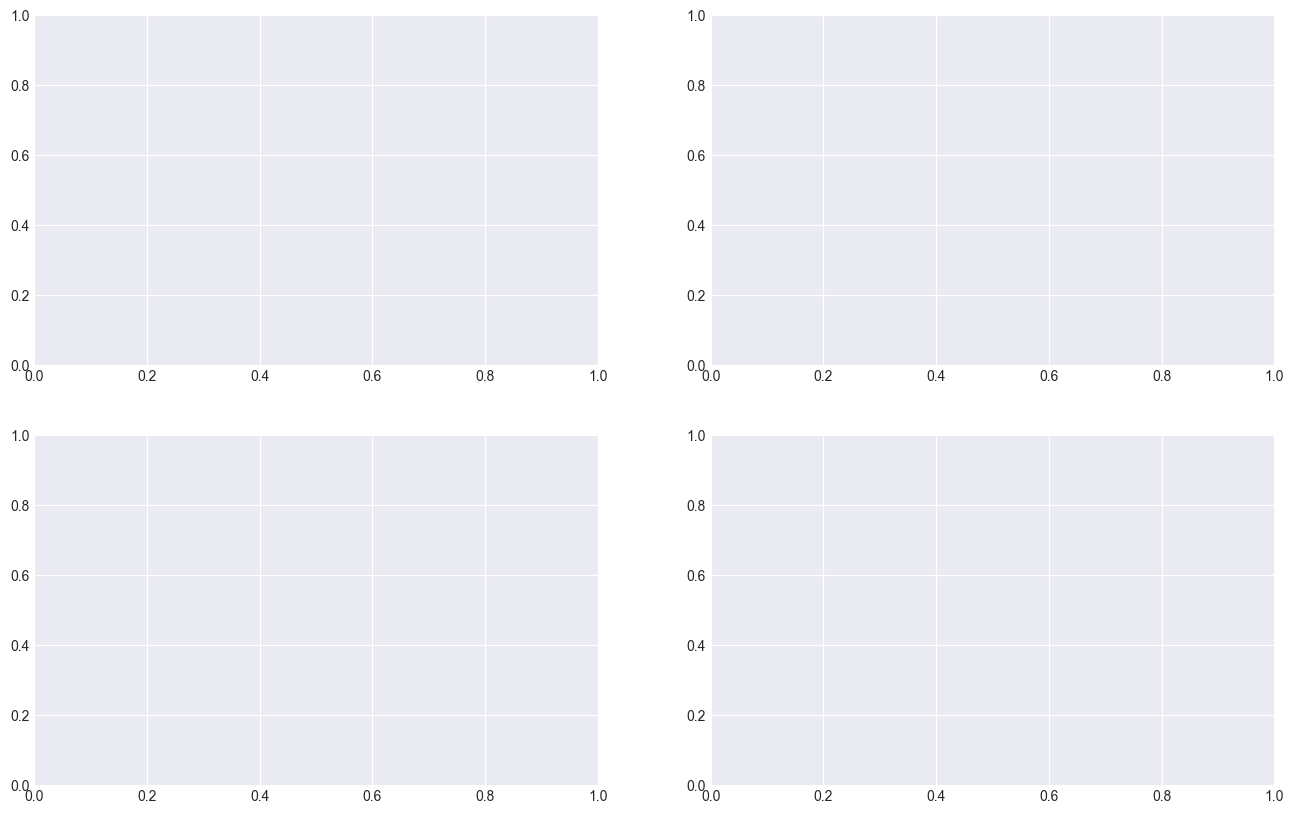

In [31]:
# Plot temporal evolution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))



'''# Total exposure
axes[1, 0].plot(timeline_df['period'], timeline_df['total_exposure'], marker='o', color='green')
axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)
# Plot temporal evolution


axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Total Exposure ($)')
axes[1, 0].set_title('Total Interbank Exposure Over Time')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)

# Rating distribution
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_A'], marker='o', label='A')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_B'], marker='s', label='B')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_C'], marker='^', label='C')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_D'], marker='v', label='D')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_E'], marker='x', label='E')
axes[1, 1].plot(timeline_df['period'], timeline_df['rating_F'], marker='d', label='F')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Number of Banks')
axes[1, 1].set_title('Credit Rating Distribution Over Time')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Key Insights Summary

Summarize the main findings from the analysis.

In [ ]:
print("=" * 80)
print("KEY INSIGHTS FROM DATA EXPLORATION")
print("=" * 80)

if 'timeline_df' in globals():
    print("
1. DATASET SIZE:")
    print(f"   - Time period: {timeline_df['year'].min()}-{timeline_df['year'].max()}")
    print(f"   - Total quarters: {len(timeline_df)}")
    if 'num_banks' in timeline_df.columns:
        print(f"   - Average banks per quarter: {timeline_df['num_banks'].mean():.0f}")
    if 'num_connections' in timeline_df.columns:
        print(f"   - Average connections per quarter: {timeline_df['num_connections'].mean():.0f}")

    print("
2. NETWORK STRUCTURE:")
    if 'avg_connections' in timeline_df.columns:
        print(f"   - Network density: {timeline_df['avg_connections'].mean():.2f} connections per bank")
    if 'total_exposure' in timeline_df.columns:
        print(f"   - Total exposure range: ${timeline_df['total_exposure'].min():,.0f} - ${timeline_df['total_exposure'].max():,.0f}")

    print("
3. CREDIT RATINGS:")
    for col, label in [
        ('rating_A', 'A'), ('rating_B', 'B'), ('rating_C', 'C'),
        ('rating_D', 'D'), ('rating_E', 'E'), ('rating_F', 'F')
    ]:
        if col in timeline_df.columns:
            print(f"   - Average {label}-rated banks: {timeline_df[col].mean():.0f}")
else:
    print("
1. DATASET SIZE: timeline_df not available (run the temporal evolution section).")

if 'test_nodes' in globals() and 'feature_cols' in globals():
    print("
4. DATA QUALITY:")
    missing = (test_nodes[feature_cols].isnull().sum() > 0).sum()
    complete = (test_nodes[feature_cols].isnull().sum() == 0).sum()
    print(f"   - Features with missing values: {missing} out of {len(feature_cols)}")
    print(f"   - Complete features: {complete}")
else:
    print("
4. DATA QUALITY: test_nodes/feature_cols not available (run the features section).")

print("
" + "=" * 80)
print("✅ Data exploration complete!")
print("=" * 80)


KEY INSIGHTS FROM DATA EXPLORATION

1. DATASET SIZE:
   - Time period: 2016-2022
   - Total quarters: 28
   - Average banks per quarter: 4548
   - Average connections per quarter: 12276

2. NETWORK STRUCTURE:
   - Network density: 2.70 connections per bank
   - Total exposure range: $87,668,687 - $1,809,295,720

3. CREDIT RATINGS:
   - Banks with ratings: ~4548 per quarter
   - Average A-rated banks: 823
   - Average B-rated banks: 1506
   - Average C-rated banks: 1490
   - Average D-rated banks: 729

4. DATA QUALITY:
   - Features with missing values: 0 out of 70
   - Complete features: 70

✅ Data exploration complete!


# Visualization with all the banks

In [ ]:
# For large networks, we'll visualize a subset
# Let's take the top 50 most connected banks
top_n = 100
top_nodes = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_node_ids = [node for node, degree in top_nodes]

# Create subgraph
G_sub = G.subgraph(top_node_ids).copy()

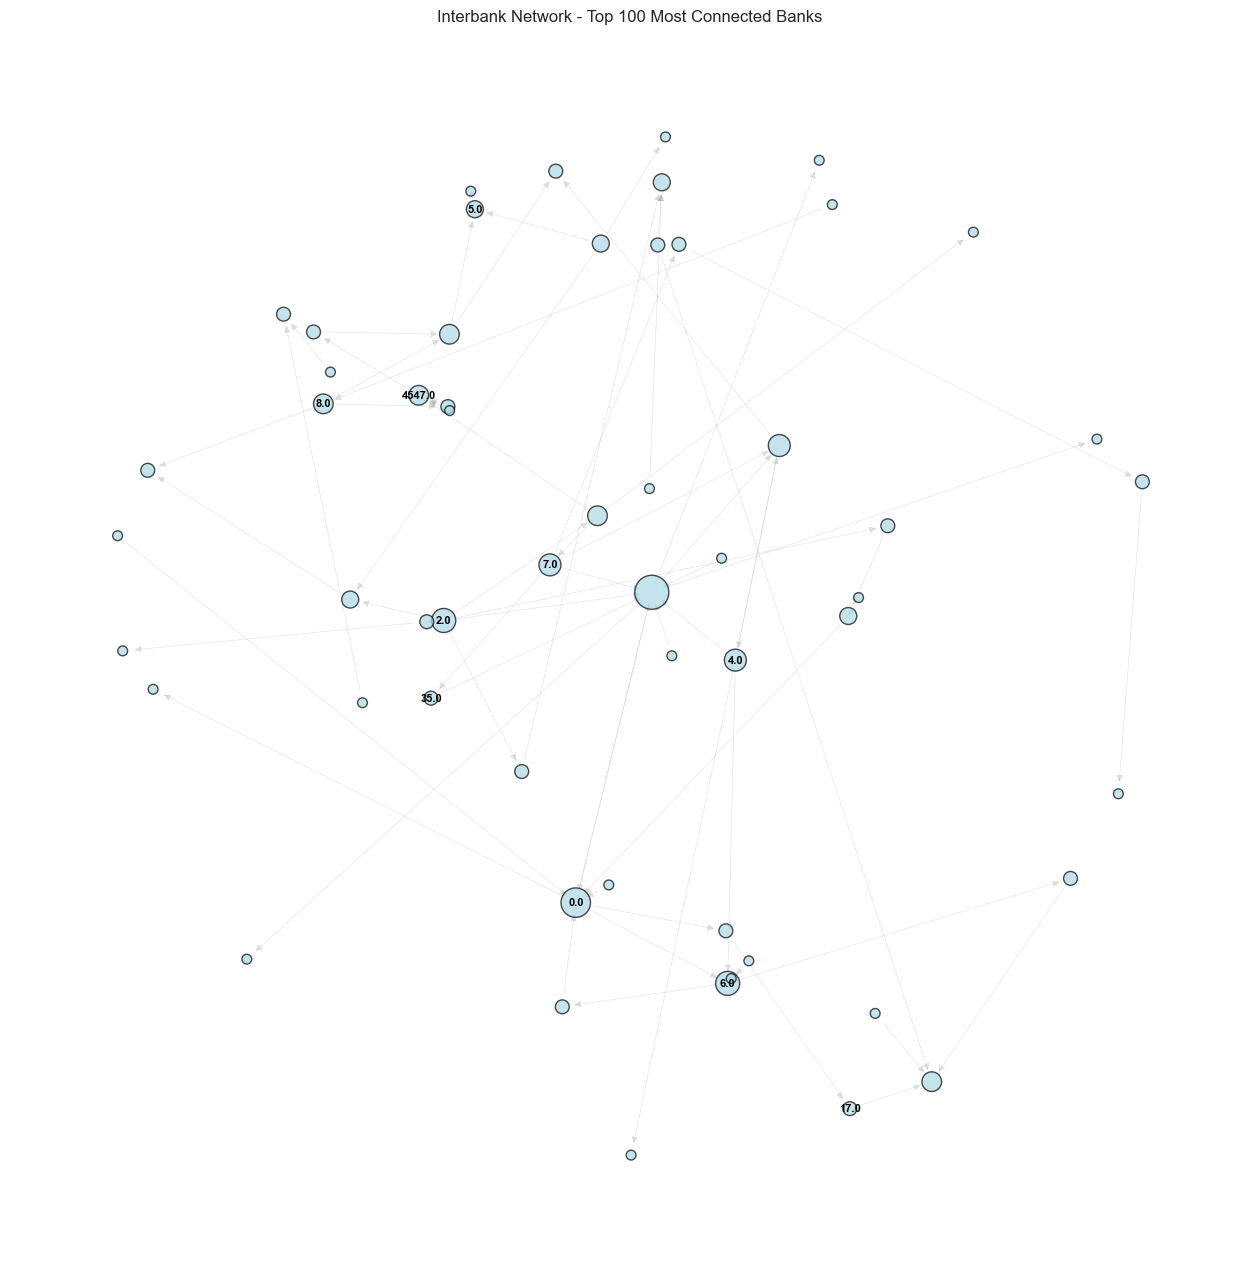

In [ ]:
plt.figure(figsize=(16, 16))

# Use spring layout for positioning
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

# Node sizes based on degree
node_sizes = [G_sub.degree(node) * 50 for node in G_sub.nodes()]

# Draw network
nx.draw_networkx_nodes(G_sub, pos, 
                       node_size=node_sizes,
                       node_color='lightblue',
                       alpha=0.7,
                       edgecolors='black')

nx.draw_networkx_edges(G_sub, pos, 
                       alpha=0.2,
                       arrows=True,
                       arrowsize=10,
                       width=0.5,
                       edge_color='gray')

# Add labels for top 10 most connected
top_10_nodes = dict(sorted(top_nodes[:10]))
labels = {node: str(node) for node in top_10_nodes.keys()}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=8, font_weight='bold')

plt.title(f'Interbank Network - Top {top_n} Most Connected Banks')
plt.axis('off')
plt.show()

In [ ]:
# Optional: install pyvis if needed
# !pip install pyvis


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   --------------------------------------- 756.0/756.0 kB 38.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pyvis.network import Network

# Create PyVis network
net = Network(height='750px', width='100%', 
              bgcolor='#222222', font_color='white',
              notebook=True, directed=True,
              cdn_resources='remote')  # Fix for Chrome/Safari display

# Add nodes with sizes based on degree
# Add nodes with sizes based on degree
for node in G_sub.nodes():
    degree = G_sub.degree(node)
    net.add_node(int(node),  # Convert to regular Python int
                label=str(node),
                size=degree*2,
                title=f'Bank {node}<br>Degree: {degree}',
                color='#00ff1e')

# Add edges
for source, target, data in G_sub.edges(data=True):
    weight = data.get('weight', 1)
    net.add_edge(int(source), int(target),  # Convert to regular Python int
                value=weight/1000,
                title=f'Exposure: ${weight:,.0f}')

# Show the network
net.show('network_visualization.html')

network_visualization.html
